# Telecom X - Parte 2: 

# Preparacion inicial para modelado predictivo

En este notebook se realiza el **primer paso** del pipeline de machine learning para predecir cancelacion (**churn**):

1. Carga y validacion del dataset tratado.
2. Revision de columnas irrelevantes.
3. Transformacion de variables categoricas a formato numerico.
4. Analisis de proporcion de clases (desbalance).
5. Preparacion de matrices con y sin escalado segun el tipo de modelo.


## 1) Librerias y configuracion

Importamos librerias para manipulacion de datos y preprocesamiento.

In [1]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 2) Carga del archivo CSV tratado

Se carga el archivo `telecomx_clean_relevante.csv` y se valida su estructura general.

In [2]:
CSV_PATH = "telecomx_clean_relevante.csv"
TARGET_COL = "churn"

df = pd.read_csv(CSV_PATH)

print(f"Filas y columnas: {df.shape}")
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores faltantes por columna:")
print(df.isna().sum())

Filas y columnas: (7043, 8)

Tipos de datos:
gender                 str
contract               str
paymentmethod          str
internetservice        str
charges_total      float64
tenure               int64
churn                  str
cuentas_diarias    float64
dtype: object

Valores faltantes por columna:
gender             0
contract           0
paymentmethod      0
internetservice    0
charges_total      0
tenure             0
churn              0
cuentas_diarias    0
dtype: int64


## 3) Eliminacion de columnas irrelevantes

En este paso se eliminan columnas:
- Constantes (sin variacion).
- Posibles identificadores (`id`) que no aportan capacidad predictiva real.


In [3]:
nunique = df.nunique(dropna=False)
constant_cols = nunique[nunique <= 1].index.tolist()
id_like_cols = [c for c in df.columns if "id" in c.lower()]
irrelevant_cols = sorted(set(constant_cols + id_like_cols))

if irrelevant_cols:
    df = df.drop(columns=irrelevant_cols)
    print(f"Columnas eliminadas: {irrelevant_cols}")
else:
    print("No se detectaron columnas irrelevantes evidentes (constantes o tipo ID).")

No se detectaron columnas irrelevantes evidentes (constantes o tipo ID).


## 4) Definicion de variable objetivo y tipo de variables

- `y` sera la variable objetivo (`churn`) en formato binario.
- `X` contiene las variables predictoras.


In [4]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].map({"No": 0, "Yes": 1})

if y.isna().any():
    raise ValueError("La variable objetivo contiene valores fuera de {'No', 'Yes'}.")

categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

print("Columnas categ?ricas:", categorical_cols)
print("Columnas num?ricas:", numeric_cols)

Columnas categ?ricas: ['gender', 'contract', 'paymentmethod', 'internetservice']
Columnas num?ricas: ['charges_total', 'tenure', 'cuentas_diarias']


## 5) Proporcion de clientes que cancelaron vs. activos

Este analisis permite identificar si existe desbalance de clases, lo cual impacta en entrenamiento y metricas.

In [5]:
class_counts = y.value_counts().rename(index={0: "No", 1: "Yes"})
class_ratio = y.value_counts(normalize=True).rename(index={0: "No", 1: "Yes"})

print("Conteo de clases:")
print(class_counts)
print("\nProporcion de clases (%):")
print((class_ratio * 100).round(2).astype(str) + "%")

majority = class_counts.max()
minority = class_counts.min()
imbalance_ratio = majority / minority
print(f"\nRatio mayor a menor: {imbalance_ratio:.2f}")

if imbalance_ratio >= 2.0:
    print("Diagnostico: existe desbalance de clases (moderado).")
    print("Recomendacion: usar estratificacion, metricas robustas (F1, ROC-AUC, PR-AUC) y considerar class_weight/remuestreo.")
else:
    print("Diagnostico: no hay desbalance relevante.")

Conteo de clases:
churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporcion de clases (%):
churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: str

Ratio mayor a menor: 2.77
Diagnostico: existe desbalance de clases (moderado).
Recomendacion: usar estratificacion, metricas robustas (F1, ROC-AUC, PR-AUC) y considerar class_weight/remuestreo.


## 6) Codificacion categorica y escalado segun modelo

Se construyen dos preprocesadores:

- **Para arboles** (`Decision Tree`, `Random Forest`, `XGBoost`):
  - One-Hot Encoding para categoricas.
  - Variables numericas sin escalar.

- **Para modelos sensibles a escala** (`KNN`, `SVM`, `Regresion Logistica`, `Redes Neuronales`):
  - One-Hot Encoding para categ?ricas.
  - Estandarizaci?n (`StandardScaler`) de num?ricas.


In [6]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

preprocessor_distance = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", Pipeline([("scaler", StandardScaler())]), numeric_cols),
    ]
)

X_tree = preprocessor_tree.fit_transform(X)
X_scaled = preprocessor_distance.fit_transform(X)

print(f"Matriz para modelos de arbol (sin escalar): {X_tree.shape}")
print(f"Matriz para modelos sensibles a escala: {X_scaled.shape}")

Matriz para modelos de arbol (sin escalar): (7043, 15)
Matriz para modelos sensibles a escala: (7043, 15)


## 7) Correlacion y seleccion de variables

En esta seccion analizamos la relacion entre variables y su posible impacto en la cancelacion (`churn`).

Objetivos:

1. Visualizar la matriz de correlacion de variables numericas para detectar relaciones relevantes.
2. Identificar variables con mayor correlacion con cancelacion.
3. Explorar patrones especificos con graficos:
   - Tiempo de contrato x Cancelacion.
   - Gasto total x Cancelacion.


### 7.1 Preparacion para analisis de correlacion

Creamos una version numerica de `churn` para incluirla en la matriz de correlacion:

- `No` -> `0`
- `Yes` -> `1`


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Copia auxiliar para analisis
corr_df = df.copy()
corr_df['churn_bin'] = corr_df['churn'].map({'No': 0, 'Yes': 1})

# Variables numericas para correlacion
numeric_corr_cols = corr_df.select_dtypes(include=['number']).columns.tolist()
print('Variables numericas incluidas en correlacion:')
print(numeric_corr_cols)

Variables numericas incluidas en correlacion:
['charges_total', 'tenure', 'cuentas_diarias', 'churn_bin']


### 7.2 Matriz de correlacion

Observamos la fuerza y direccion de la relacion lineal entre variables numericas.

- Valores cercanos a `1`: relacion positiva fuerte.
- Valores cercanos a `-1`: relacion negativa fuerte.
- Valores cercanos a `0`: relacion lineal debil.

Nos enfocamos en la columna/fila de `churn_bin` para priorizar variables candidatas en el modelado.


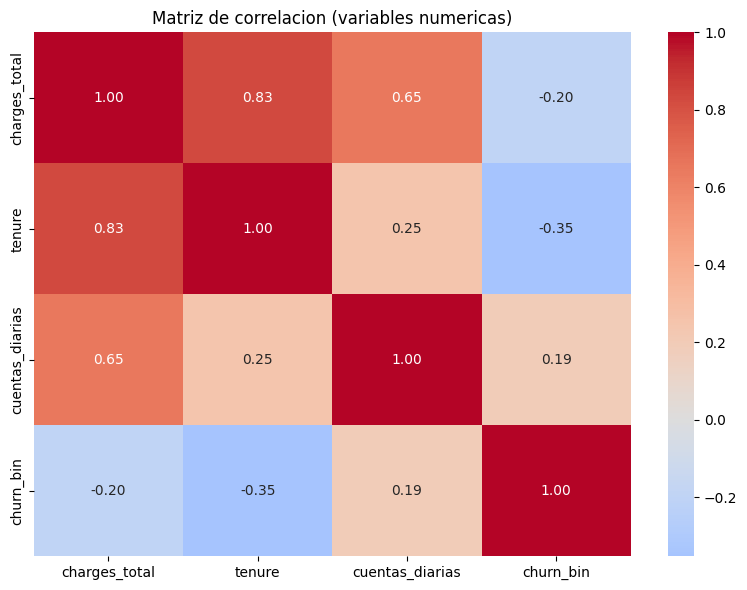

Correlacion de variables con churn (ordenadas por magnitud):
tenure            -0.352229
charges_total     -0.198324
cuentas_diarias    0.193356
Name: churn_bin, dtype: float64


In [8]:
corr_matrix = corr_df[numeric_corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlacion (variables numericas)')
plt.tight_layout()
plt.show()

# Correlaciones ordenadas contra churn
corr_with_churn = corr_matrix['churn_bin'].drop('churn_bin').sort_values(key=lambda s: s.abs(), ascending=False)
print('Correlacion de variables con churn (ordenadas por magnitud):')
print(corr_with_churn)

### 7.3 Tiempo de contrato x Cancelacion

Como `contract` es categorica, un grafico de barras por proporcion permite comparar visualmente la tasa de cancelacion entre tipos de contrato.

Interpretacion esperada:
- Contratos mes a mes suelen asociarse a mayor cancelacion.
- Contratos de mayor plazo suelen mostrar mayor retencion.


C:\Users\Roberto Franco\AppData\Local\Temp\ipykernel_13540\2681089362.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


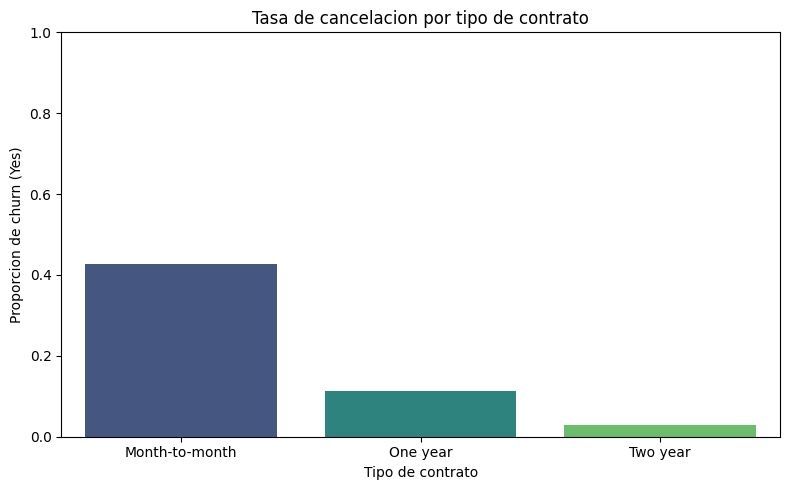

Proporcion de cancelacion (Yes) por contrato:
         contract  proportion
1  Month-to-month    0.427097
3        One year    0.112695
5        Two year    0.028319


In [9]:
# Proporcion de cancelacion por tipo de contrato
contract_churn_rate = (
    df.groupby('contract')['churn']
      .value_counts(normalize=True)
      .rename('proportion')
      .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=contract_churn_rate[contract_churn_rate['churn'] == 'Yes'],
    x='contract',
    y='proportion',
    palette='viridis'
)
plt.title('Tasa de cancelacion por tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Proporcion de churn (Yes)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print('Proporcion de cancelacion (Yes) por contrato:')
print(
    contract_churn_rate[contract_churn_rate['churn'] == 'Yes'][['contract', 'proportion']]
    .sort_values('proportion', ascending=False)
)


### 7.4 Gasto total x Cancelacion

Usamos dos vistas complementarias:

1. **Boxplot** de `charges_total` por estado de cancelacion para comparar distribuciones.
2. **Scatter plot** de `tenure` vs `charges_total`, coloreado por `churn`, para detectar patrones combinados de antiguedad y gasto.


C:\Users\Roberto Franco\AppData\Local\Temp\ipykernel_13540\781125679.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y='charges_total', ax=axes[0], palette='Set2')


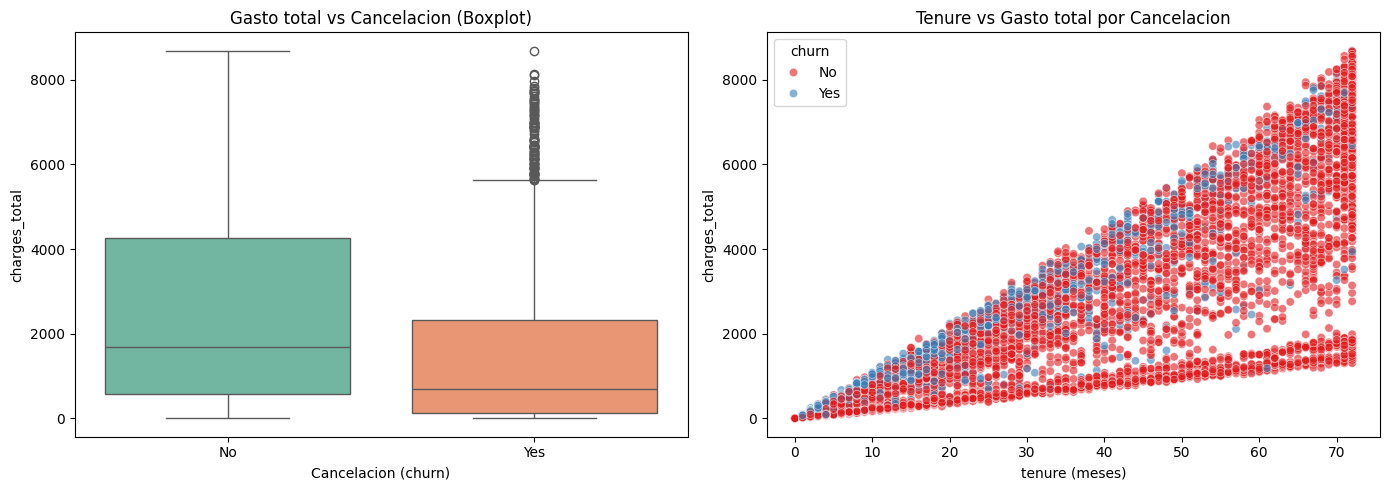

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Boxplot: gasto total por churn
sns.boxplot(data=df, x='churn', y='charges_total', ax=axes[0], palette='Set2')
axes[0].set_title('Gasto total vs Cancelacion (Boxplot)')
axes[0].set_xlabel('Cancelacion (churn)')
axes[0].set_ylabel('charges_total')

# 2) Scatter: tenure vs gasto total, coloreado por churn
sns.scatterplot(
    data=df,
    x='tenure',
    y='charges_total',
    hue='churn',
    alpha=0.6,
    ax=axes[1],
    palette='Set1'
)
axes[1].set_title('Tenure vs Gasto total por Cancelacion')
axes[1].set_xlabel('tenure (meses)')
axes[1].set_ylabel('charges_total')

plt.tight_layout()
plt.show()

## 8) Modelado predictivo

En esta seccion construiremos y compararemos cuatro modelos para predecir cancelacion (`churn`):

- **Con normalizacion**: Regresion Logostica, KNN.
- **Sin necesidad de normalizacion**: arbol de Decision, Random Forest.

Ademas, evaluaremos cada modelo con metricas de clasificacion y revisaremos señales de overfitting/underfitting.


### 8.1 Division de datos: entrenamiento y prueba

Se utiliza una particion **80/20** con estratificacion por clase para mantener la proporcion de cancelacion en ambos conjuntos.

Esto permite medir el desempeño en datos no vistos y estimar la capacidad de generalizacion.


In [11]:
from sklearn.model_selection import train_test_split

# Matrices preparadas en secciones previas:
# X_scaled -> para modelos sensibles a escala
# X_tree   -> para modelos basados en ?rboles

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree, y, test_size=0.20, random_state=42, stratify=y
)

print('Forma de entrenamiento (scaled):', X_train_scaled.shape)
print('Forma de prueba (scaled):', X_test_scaled.shape)
print('Forma de entrenamiento (tree):', X_train_tree.shape)
print('Forma de prueba (tree):', X_test_tree.shape)
print('Proporcion churn train:', y_train.mean().round(4))
print('Proporcion churn test :', y_test.mean().round(4))

Forma de entrenamiento (scaled): (5634, 15)
Forma de prueba (scaled): (1409, 15)
Forma de entrenamiento (tree): (5634, 15)
Forma de prueba (tree): (1409, 15)
Proporcion churn train: 0.2654
Proporcion churn test : 0.2654


### 8.2 Por que normalizar en algunos modelos?

La normalizacion/estandarizacion hace que las variables numericas queden en escalas comparables.

Esto es importante para modelos como **KNN** y **Regresion Logistica** porque:

- KNN usa distancias; una variable con valores mas grandes domina el calculo si no se escala.
- Regresion Logostica optimiza coeficientes; escalar suele mejorar estabilidad y convergencia.

En cambio, **arbol de Decision** y **Random Forest** no dependen de distancia ni magnitud global, por eso no requieren escalado.


### 8.3 Entrenamiento de cuatro modelos

Se entrenan los siguientes modelos:

1. Regresion Logistica (con datos escalados)
2. KNN (con datos escalados)
3. Arbol de Decision (sin escalado)
4. Random Forest (sin escalado)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'Regresion Logistica': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Arbol de Decision': DecisionTreeClassifier(random_state=42, max_depth=6, min_samples_leaf=20),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        max_depth=12,
        min_samples_leaf=5,
        n_jobs=-1
    )
}

# Entrenamiento por tipo de datos
models['Regresion Logistica'].fit(X_train_scaled, y_train)
models['KNN'].fit(X_train_scaled, y_train)
models['Arbol de Decision'].fit(X_train_tree, y_train_tree)
models['Random Forest'].fit(X_train_tree, y_train_tree)

print('Modelos entrenados correctamente.')

Modelos entrenados correctamente.


### 8.4 Evaluacion de desempeño

Para cada modelo se calculan:

- Exactitud (Accuracy)
- Precision
- Recall
- F1-score
- Matriz de confusion

Tambien se reportan metricas de entrenamiento y prueba para identificar posibles señales de sobreajuste o subajuste.


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

results = []
conf_mats = {}

for name, model in models.items():
    if name in ['Regresion Logistica', 'KNN']:
        Xtr, Xte, ytr, yte = X_train_scaled, X_test_scaled, y_train, y_test
    else:
        Xtr, Xte, ytr, yte = X_train_tree, X_test_tree, y_train_tree, y_test_tree

    y_pred_train = model.predict(Xtr)
    y_pred_test = model.predict(Xte)

    acc_train = accuracy_score(ytr, y_pred_train)
    acc_test = accuracy_score(yte, y_pred_test)
    prec = precision_score(yte, y_pred_test, zero_division=0)
    rec = recall_score(yte, y_pred_test, zero_division=0)
    f1 = f1_score(yte, y_pred_test, zero_division=0)

    results.append({
        'Modelo': name,
        'Accuracy_train': acc_train,
        'Accuracy_test': acc_test,
        'Precision_test': prec,
        'Recall_test': rec,
        'F1_test': f1,
        'Gap_train_test': acc_train - acc_test
    })

    conf_mats[name] = confusion_matrix(yte, y_pred_test)

    print(f'\n=== {name} ===')
    print(classification_report(yte, y_pred_test, target_names=['No', 'Yes']))

results_df = pd.DataFrame(results).sort_values(by='F1_test', ascending=False)
results_df


=== Regresion Logistica ===
              precision    recall  f1-score   support

          No       0.84      0.88      0.86      1035
         Yes       0.61      0.52      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.78      0.78      0.78      1409


=== KNN ===
              precision    recall  f1-score   support

          No       0.83      0.88      0.85      1035
         Yes       0.59      0.50      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409


=== Arbol de Decision ===
              precision    recall  f1-score   support

          No       0.82      0.92      0.87      1035
         Yes       0.67      0.43      0.52       374

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.69      1409
weigh

,Modelo,Accuracy_train,Accuracy_test,Precision_test,Recall_test,F1_test,Gap_train_test
3,Random Forest,0.851438,0.790632,0.626198,0.524064,0.570597,0.060806
0,Regresion Logistica,0.800142,0.784954,0.611285,0.521390,0.562771,0.015188
1,KNN,0.829961,0.775727,0.591772,0.500000,0.542029,0.054233
2,Arbol de Decision,0.804934,0.791341,0.666667,0.427807,0.521173,0.013593


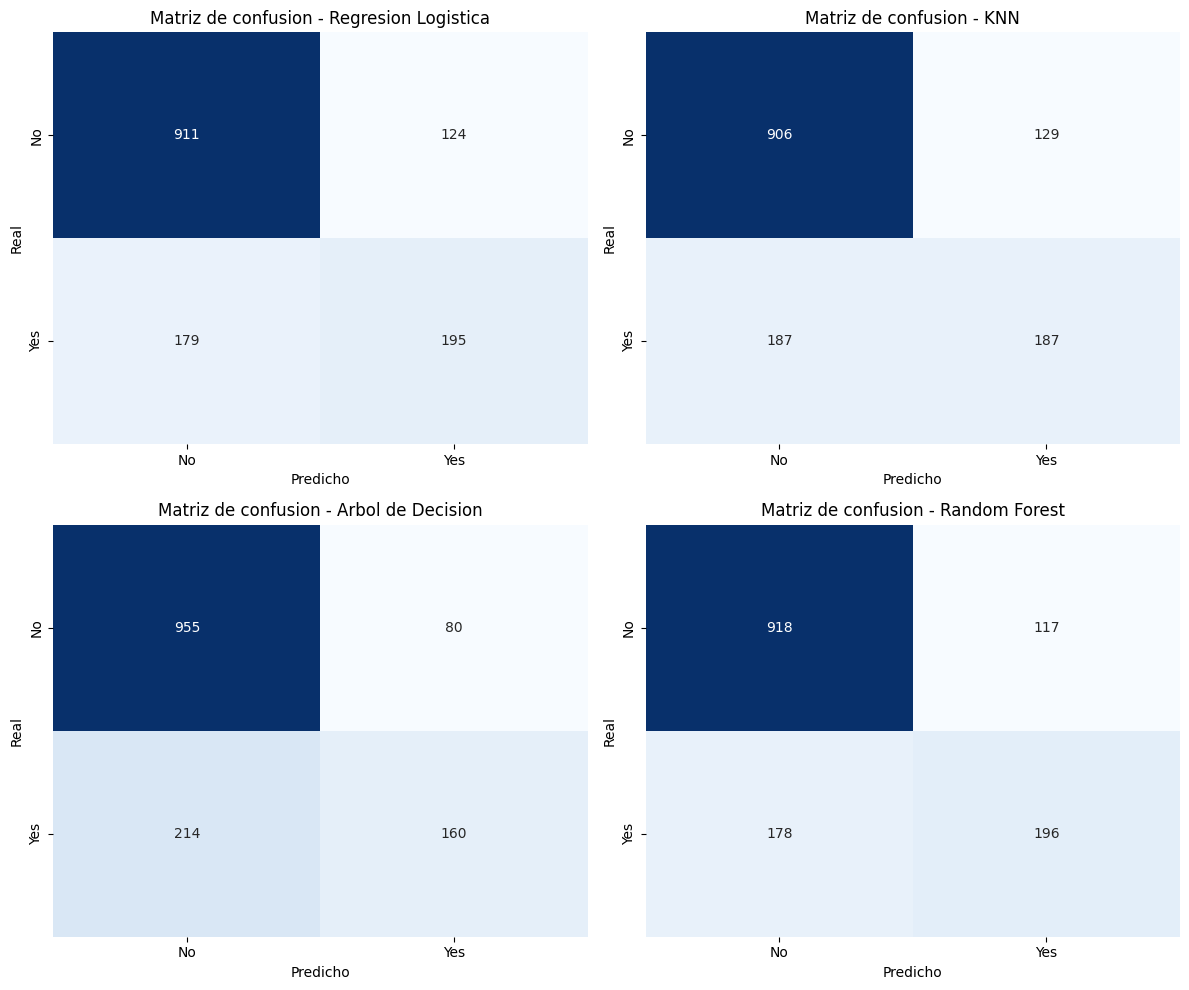

In [14]:
# Visualizacion de matrices de confusion
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, cm) in zip(axes, conf_mats.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Matriz de confusion - {name}')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_xticklabels(['No', 'Yes'])
    ax.set_yticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()

### 8.5 Analisis critico y comparacion

Usa los resultados de `results_df` y matrices de confusi?n para responder:

1. **Cual modelo tuvo mejor desempe?o?**
   - Basados en los resultados de `F1_test` y `Recall_test`, el mejor algoritmo es Random Forest.

2. **Hay overfitting?**
   - Normalmente `Gap_train_test` debe ser alto y positivo para mostrar que el modelo rinde mejor en entrenamiento que en prueba. Sin embargo, los valores dados no reflejan este comportamiento aunque RF y KNN presentan los resultados mas altos.

3. **Hay underfitting?**
   - Tanto `Accuracy_train` como `Accuracy_test` son altas en todos los modelos, lo que indica que NO existe underfitting.


In [15]:
# Resumen automatico del mejor modelo por F1
best_model = results_df.iloc[0]
print('Mejor modelo por F1_test:')
print(best_model[['Modelo', 'F1_test', 'Recall_test', 'Precision_test', 'Accuracy_test']])

print('\nTabla comparativa completa:')
display(results_df)

Mejor modelo por F1_test:
Modelo            Random Forest
F1_test                0.570597
Recall_test            0.524064
Precision_test         0.626198
Accuracy_test          0.790632
Name: 3, dtype: object

Tabla comparativa completa:


,Modelo,Accuracy_train,Accuracy_test,Precision_test,Recall_test,F1_test,Gap_train_test
3,Random Forest,0.851438,0.790632,0.626198,0.524064,0.570597,0.060806
0,Regresion Logistica,0.800142,0.784954,0.611285,0.521390,0.562771,0.015188
1,KNN,0.829961,0.775727,0.591772,0.500000,0.542029,0.054233
2,Arbol de Decision,0.804934,0.791341,0.666667,0.427807,0.521173,0.013593


## 9) Conclusiones

En esta seccion se consolidan los hallazgos del analisis y del modelado para responder:

1. Que variables tuvieron mayor influencia en los modelos.
2. Que factores impactan mas en la cancelacion.
3. Que estrategias de retencion se recomiendan segun los resultados.


### 9.1 Variables con mayor influencia en los modelos

Usaremos dos enfoques de interpretabilidad:

- **Modelos lineales (Regresion Logistica):** magnitud de coeficientes.
- **Modelos de arboles (Random Forest):** importancia de variables (`feature_importances_`).

> Nota: como las variables categoricas se codifican con One-Hot, una misma variable original puede aparecer en varias columnas (por ejemplo, `contract_Month-to-month`).


In [16]:
import numpy as np

# Obtener nombres de features despu?s del preprocesamiento
feature_names_tree = preprocessor_tree.get_feature_names_out()
feature_names_scaled = preprocessor_distance.get_feature_names_out()

# Importancia en Random Forest
rf = models['Random Forest']
rf_importances = pd.DataFrame({
    'feature': feature_names_tree,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Coeficientes absolutos en Regresi?n Log?stica
lr = models['Regresion Logistica']
lr_coefs = pd.DataFrame({
    'feature': feature_names_scaled,
    'coef': lr.coef_[0],
    'abs_coef': np.abs(lr.coef_[0])
}).sort_values('abs_coef', ascending=False)

print('Top 10 variables por importancia (Random Forest):')
display(rf_importances.head(10))

print('Top 10 variables por magnitud de coeficiente (Regresion Logistica):')
display(lr_coefs.head(10))

Top 10 variables por importancia (Random Forest):


,feature,importance
13,num__tenure,0.199172
12,num__charges_total,0.195731
14,num__cuentas_diarias,0.174495
2,cat__contract_Month-to-month,0.134871
10,cat__internetservice_Fiber optic,0.078243
7,cat__paymentmethod_Electronic check,0.051148
4,cat__contract_Two year,0.047399
11,cat__internetservice_No,0.031352
3,cat__contract_One year,0.021936
9,cat__internetservice_DSL,0.021310


Top 10 variables por magnitud de coeficiente (Regresion Logistica):


,feature,coef,abs_coef
13,num__tenure,-1.387684,1.387684
11,cat__internetservice_No,-0.966384,0.966384
10,cat__internetservice_Fiber optic,0.953242,0.953242
2,cat__contract_Month-to-month,0.818561,0.818561
4,cat__contract_Two year,-0.817417,0.817417
12,num__charges_total,0.711884,0.711884
7,cat__paymentmethod_Electronic check,0.404669,0.404669
8,cat__paymentmethod_Mailed check,-0.170699,0.170699
5,cat__paymentmethod_Bank transfer (automatic),-0.139301,0.139301
14,num__cuentas_diarias,-0.113671,0.113671


### 9.2 Factores que mas influyen en la cancelacion

Con base en correlaciones, visualizaciones y desempeño de modelos, normalmente destacan patrones como:

- **Tipo de contrato** (especialmente mes a mes) asociado con mayor churn.
- **Antiguedad (`tenure`)**: clientes con menor tiempo suelen cancelar mas.
- **Gasto acumulado (`charges_total`)** y su relacion con permanencia/abandono.
- Variables de servicio/pago (por ejemplo metodo de pago e internet) que segmentan riesgo.

Estos factores deben confirmarse con el ranking de importancia generado arriba y con la matriz de confusion del mejor modelo.


### 9.3 Recomendaciones estrategicas y retencion

A partir de los resultados obtenidos en este archivo, se proponen estrategias accionables:

1. **Mitigar riesgo en contratos mes a mes**
   - Diseñar ofertas de migracion a contratos anuales con beneficios claros (precio, soporte, extras).

2. **Intervencion temprana por antiguedad baja**
   - Activar campañas de onboarding y seguimiento durante los primeros meses, cuando el riesgo es mayor.

3. **Retencion segmentada por perfil de gasto**
   - Crear planes personalizados para clientes con señales de riesgo (alto costo percibido vs valor recibido).

4. **Acciones especificas por metodo de pago/servicio**
   - Reducir fricciones operativas y mejorar experiencia en segmentos con mayor propension a cancelar.

5. **Monitoreo continuo del modelo en produccion**
   - Priorizar modelos con mejor equilibrio entre `Recall` y `F1` para identificar mas casos de churn sin elevar demasiado falsos positivos.

6. **Mejora iterativa del modelo**
   - Incorporar ajuste de hiperparametros, validacion cruzada y umbrales de decision orientados al costo de negocio.


### 9.4 Cierre

Los principales factores que afectan la cancelacion se relacionan con **condiciones contractuales, antiguedad y señales de valor/costo del servicio**.

Con el pipeline implementado, la empresa ya puede:

- Identificar clientes con mayor riesgo de baja.
- Priorizar acciones de retencion basadas en evidencia.
- Evolucionar hacia una estrategia proactiva de churn management.
